# Fraud Detection Dataset - Exploratory Data Analysis

# 1. Fraud Definition

Fraud refers to the intentional act of deception carried out to obtain an unfair or unlawful financial advantage. It typically involves falsification, identity manipulation, or other criminal activities that result in financial losses.

Fraud frequently occurs in banking systems and digital platforms, particularly in cases such as phishing attacks, identity theft, and payment fraud.

---

## Cost of Misclassification in Fraud Detection

Fraud detection models must balance two critical types of errors:

### False Negative (FN)
A fraudulent transaction is incorrectly classified as legitimate.  
This is the most costly error for financial institutions because it directly results in financial losses.

### False Positive (FP)
A legitimate transaction is incorrectly flagged as fraudulent.  
Although less financially damaging, this type of error negatively impacts customer experience and trust.

# 2. Dataset Overview

Due to confidentiality issues, the original features were transformed using Principal Component Analysis (PCA).

As a result, most features (V1–V28) are anonymized components and do not correspond to the original variables.

The only features that were not transformed are:

- Time
- Amount

## Objective

The goal of this notebook is to explore the fraud detection dataset,
understand class imbalance, and identify relevant features
for building machine learning models.

## Notebook Imports

In [92]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import plotly.express as px
import plotly.figure_factory as ff

## Import Data

In [93]:
transactions_df = pd.read_csv("../data/raw/creditcard.csv")

print("Dataset shape:", transactions_df.shape)

display(transactions_df.head())

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Data Inspection

In [94]:
transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## Exploratory Analysis

## Fraud vs Non-Fraud Distribution

Before training a model, it is important to understand the class distribution.

Fraud detection datasets are typically **highly imbalanced**, meaning fraudulent transactions represent only a very small portion of the data.

In the `Class` column:

- **0 → Not Fraud**
- **1 → Fraud**

In [95]:
transactions_df["Class"].value_counts().rename({
    0: "Not Fraud",
    1: "Fraud"
})

Class
Not Fraud    284315
Fraud           492
Name: count, dtype: int64

In [96]:
fraud_percentage = transactions_df["Class"].value_counts(normalize=True) * 100
print(fraud_percentage.round(2).to_string() + '%')

Class
0    99.83
1     0.17%


## Key Insights

The dataset is extremely imbalanced, with fraudulent transactions representing less than 0.2% of the total data.

Several PCA-transformed features show correlation with fraudulent transactions.

Further steps will include:

- Feature importance analysis
- Handling class imbalance
- Building predictive models

In [97]:
print("Credit Card Fraud Detection data -  rows:",transactions_df.shape[0]," columns:", transactions_df.shape[1])


Credit Card Fraud Detection data -  rows: 284807  columns: 31


In [98]:
transactions_df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

## Checking the Data Type

In [99]:
print(transactions_df.dtypes)

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


 The dataset contains only numerical features. Therefore, categorical encoding techniques such as One-Hot Encoding or Label Encoding are not necessary.

# 3. Data Quality Check

## Missing values

In [100]:
missing_df = pd.DataFrame({
    "column": transactions_df.columns,
    "missing_values": transactions_df.isnull().sum(),
    "missing_percent": (transactions_df.isnull().sum() / len(transactions_df)) * 100
})

missing_df = missing_df.sort_values(by="missing_percent", ascending=False)

missing_df

,column,missing_values,missing_percent
Time,Time,0,0.0
V1,V1,0,0.0
V2,V2,0,0.0
V3,V3,0,0.0
V4,V4,0,0.0
V5,V5,0,0.0
V6,V6,0,0.0
V7,V7,0,0.0
V8,V8,0,0.0
V9,V9,0,0.0


In [101]:
duplicates = transactions_df.duplicated().sum()

print("Duplicated rows:", duplicates)

transactions_df = transactions_df.drop_duplicates()

print("After removal:", transactions_df.duplicated().sum())

Duplicated rows: 1081
After removal: 0


# 4. Distribution of the target variables

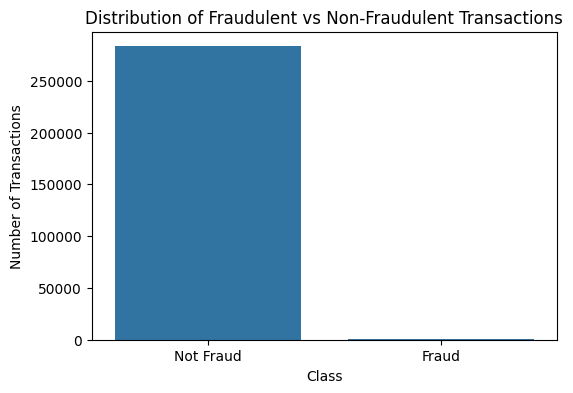

In [102]:
class_counts = transactions_df["Class"].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values)

plt.xticks([0,1], ["Not Fraud", "Fraud"])
plt.ylabel("Number of Transactions")
plt.title("Distribution of Fraudulent vs Non-Fraudulent Transactions")

plt.show()

In [103]:
class_counts = transactions_df["Class"].value_counts()

fraud_ratio = transactions_df["Class"].value_counts(normalize=True) * 100

print(fraud_ratio)

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


### Class Imbalance Observation

The dataset is highly imbalanced, with the majority of transactions labeled as **Not Fraud**.

This imbalance may bias the model toward the majority class during training, increasing the risk of poor fraud detection performance.

If not addressed, the model may learn to classify most transactions as legitimate, resulting in a high number of **false negatives**.

Therefore, the model must learn patterns associated with fraudulent activity rather than relying solely on the dominant class distribution.

### Transaction in Time

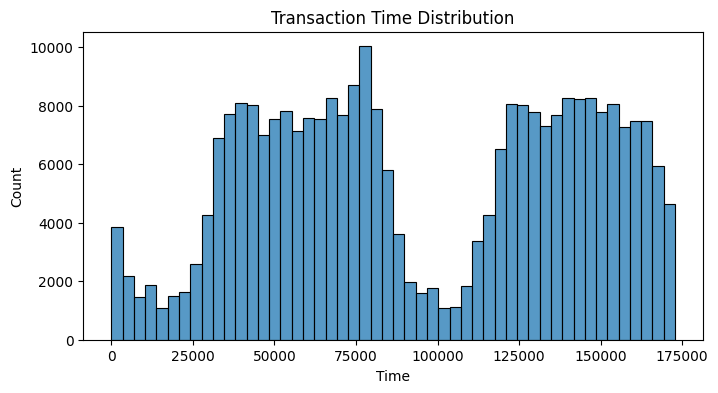

In [104]:
plt.figure(figsize=(8,4))

sns.histplot(transactions_df["Time"], bins=50)

plt.title("Transaction Time Distribution")

plt.show()

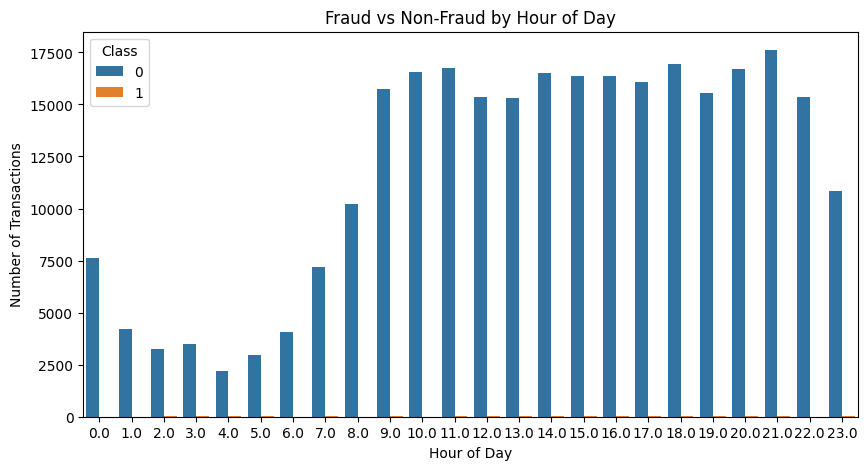

In [105]:
transactions_df["Hour"] = transactions_df["Time"] // 3600 % 24

plt.figure(figsize=(10,5))

sns.countplot(
    x="Hour",
    hue="Class",
    data=transactions_df
)

plt.title("Fraud vs Non-Fraud by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")

plt.show()

# Fraud Rate By Hour

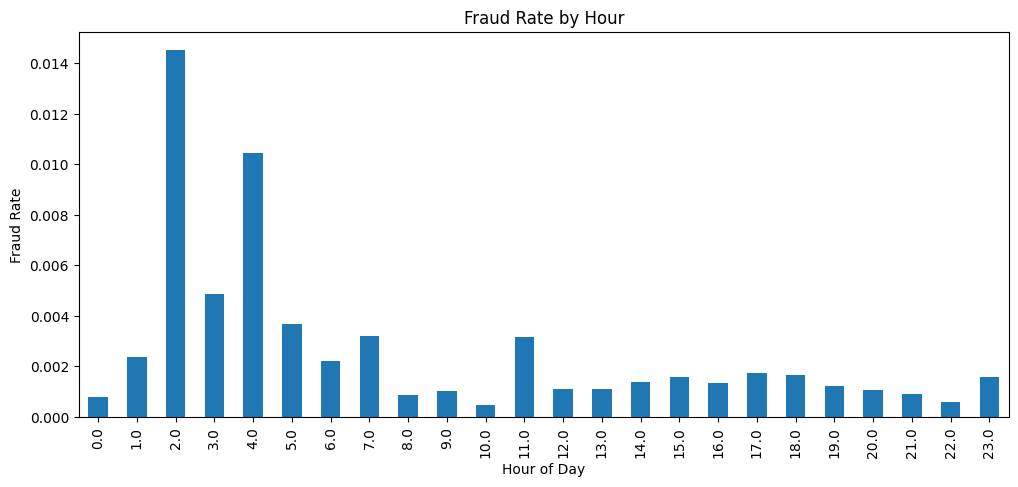

In [106]:
fraud_rate = transactions_df.groupby("Hour")["Class"].mean()

plt.figure(figsize=(12,5))
fraud_rate.plot(kind="bar")

plt.title("Fraud Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate")

plt.show()

# Fraud Rate Line visualization

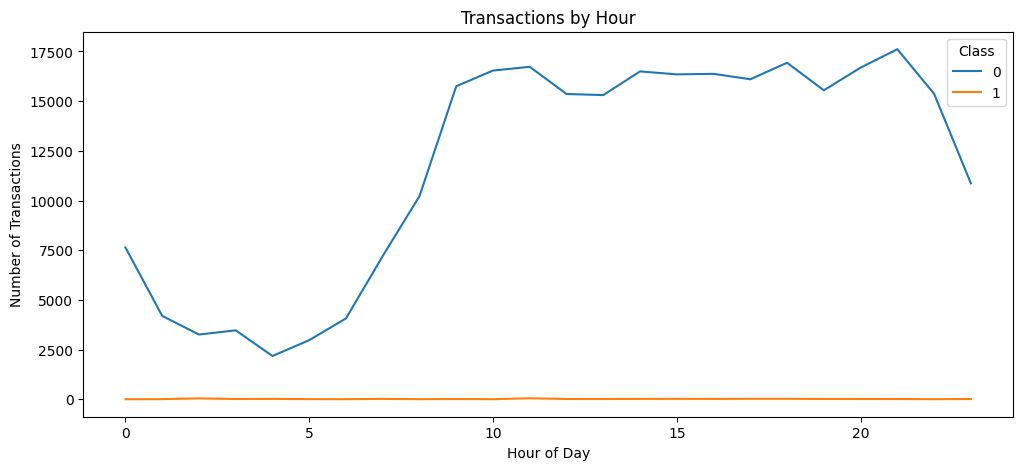

In [107]:
hourly_counts = transactions_df.groupby(["Hour","Class"]).size().unstack()

hourly_counts.plot(figsize=(12,5))

plt.title("Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")

plt.show()

### Temporal Distribution of Transactions

Fraudulent transactions exhibit a more uniform temporal distribution compared to legitimate transactions. 
While legitimate transactions follow typical daily activity patterns, fraudulent transactions appear more evenly distributed throughout the day and tend to occur more frequently during nighttime hours in European time zones.

To better understand these patterns, we analyze the time distribution of both transaction classes and compute aggregated metrics such as:

- Transaction count per hour
- Total transaction amount per hour

Based on the observed timestamp distribution, we assume that the time variable is represented in seconds.

### Ploting the amount of Transactions

NameError: name 'transactions_df2' is not defined

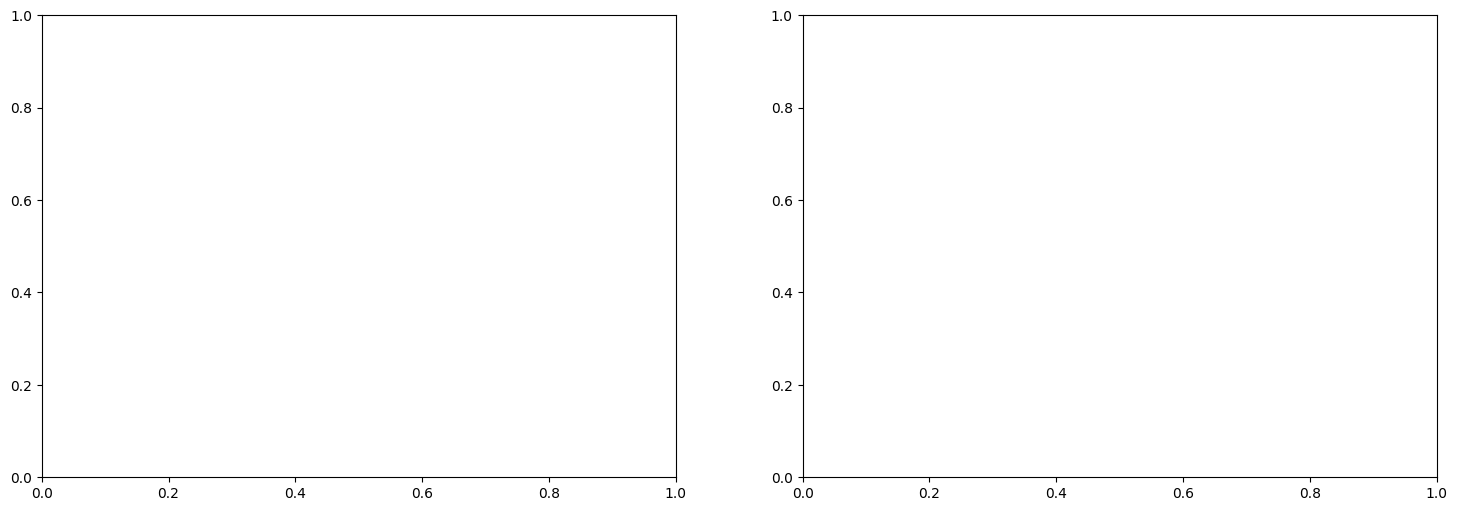

In [108]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))

s1 = sns.lineplot(ax=ax1, x="Hour", y="Amount", data=transactions_df2[transactions_df2['Class'] == 0])
s2 = sns.lineplot(ax=ax2, x="Hour", y="Amount", data=transactions_df2[transactions_df2['Class'] == 1], color="red")

plt.suptitle("Total Number of Transactions")
plt.show()

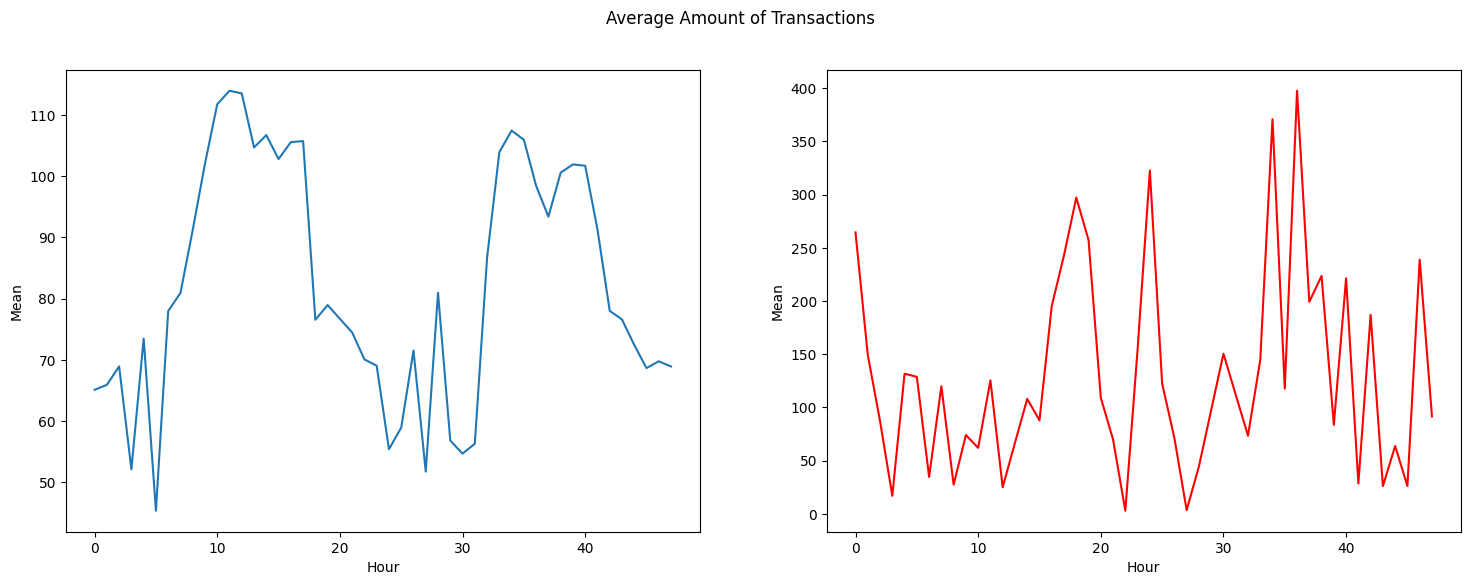

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))

s1 = sns.lineplot(ax=ax1, x="Hour", y="Mean", data=df[df['Class'] == 0])
s2 = sns.lineplot(ax=ax2, x="Hour", y="Mean", data=df[df['Class'] == 1], color="red")

plt.suptitle("Average Amount of Transactions")
plt.show()

### Checking the classes distruibution

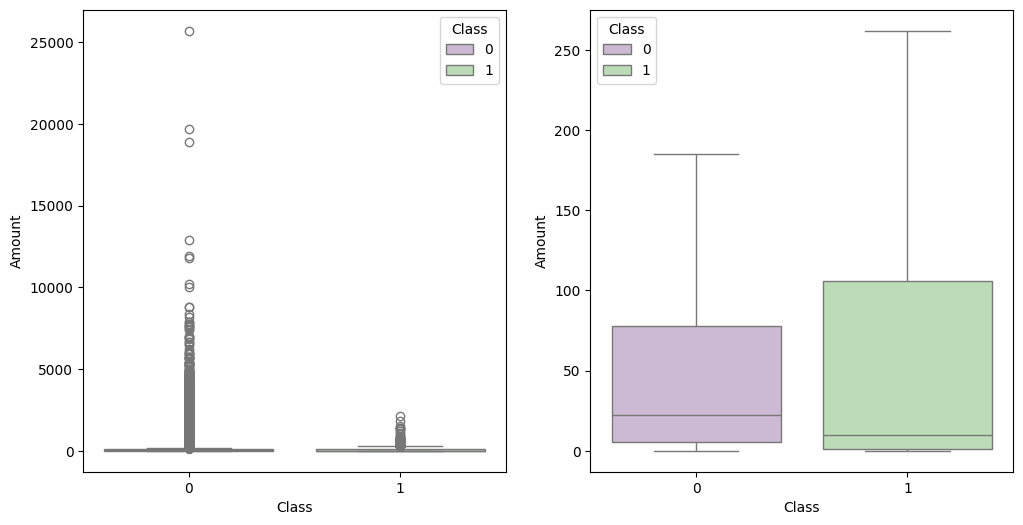

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,6))
s = sns.boxplot(ax = ax1, x="Class", y="Amount", hue="Class",data=transactions_df2, palette="PRGn",showfliers=True)
s = sns.boxplot(ax = ax2, x="Class", y="Amount", hue="Class",data=transactions_df2, palette="PRGn",showfliers=False)
plt.show();

From the distribution, we observe that legitimate transactions contain a higher number of outliers. 
Fraudulent transactions, however, tend to follow a more consistent pattern in their distribution.

In [ ]:
tmp = transactions_df2[['Amount','Class']].copy()
class_0 = tmp.loc[tmp['Class'] == 0]['Amount']
class_1 = tmp.loc[tmp['Class'] == 1]['Amount']
class_0.describe()

count    283253.000000
mean         88.413575
std         250.379023
min           0.000000
25%           5.670000
50%          22.000000
75%          77.460000
max       25691.160000
Name: Amount, dtype: float64

In [ ]:
class_1.describe()


count     473.000000
mean      123.871860
std       260.211041
min         0.000000
25%         1.000000
50%         9.820000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

### Transaction Amount Distribution

Legitimate transactions generally present higher mean values and higher lower quartile values (Q1) compared to fraudulent transactions. 
Fraudulent transactions, however, show relatively higher upper quartile values and a distinct outlier pattern.


Due to the strong class imbalance in the dataset, evaluation metrics such as Precision-Recall AUC and F1-score are prioritized over accuracy.

### Correlation Matrix

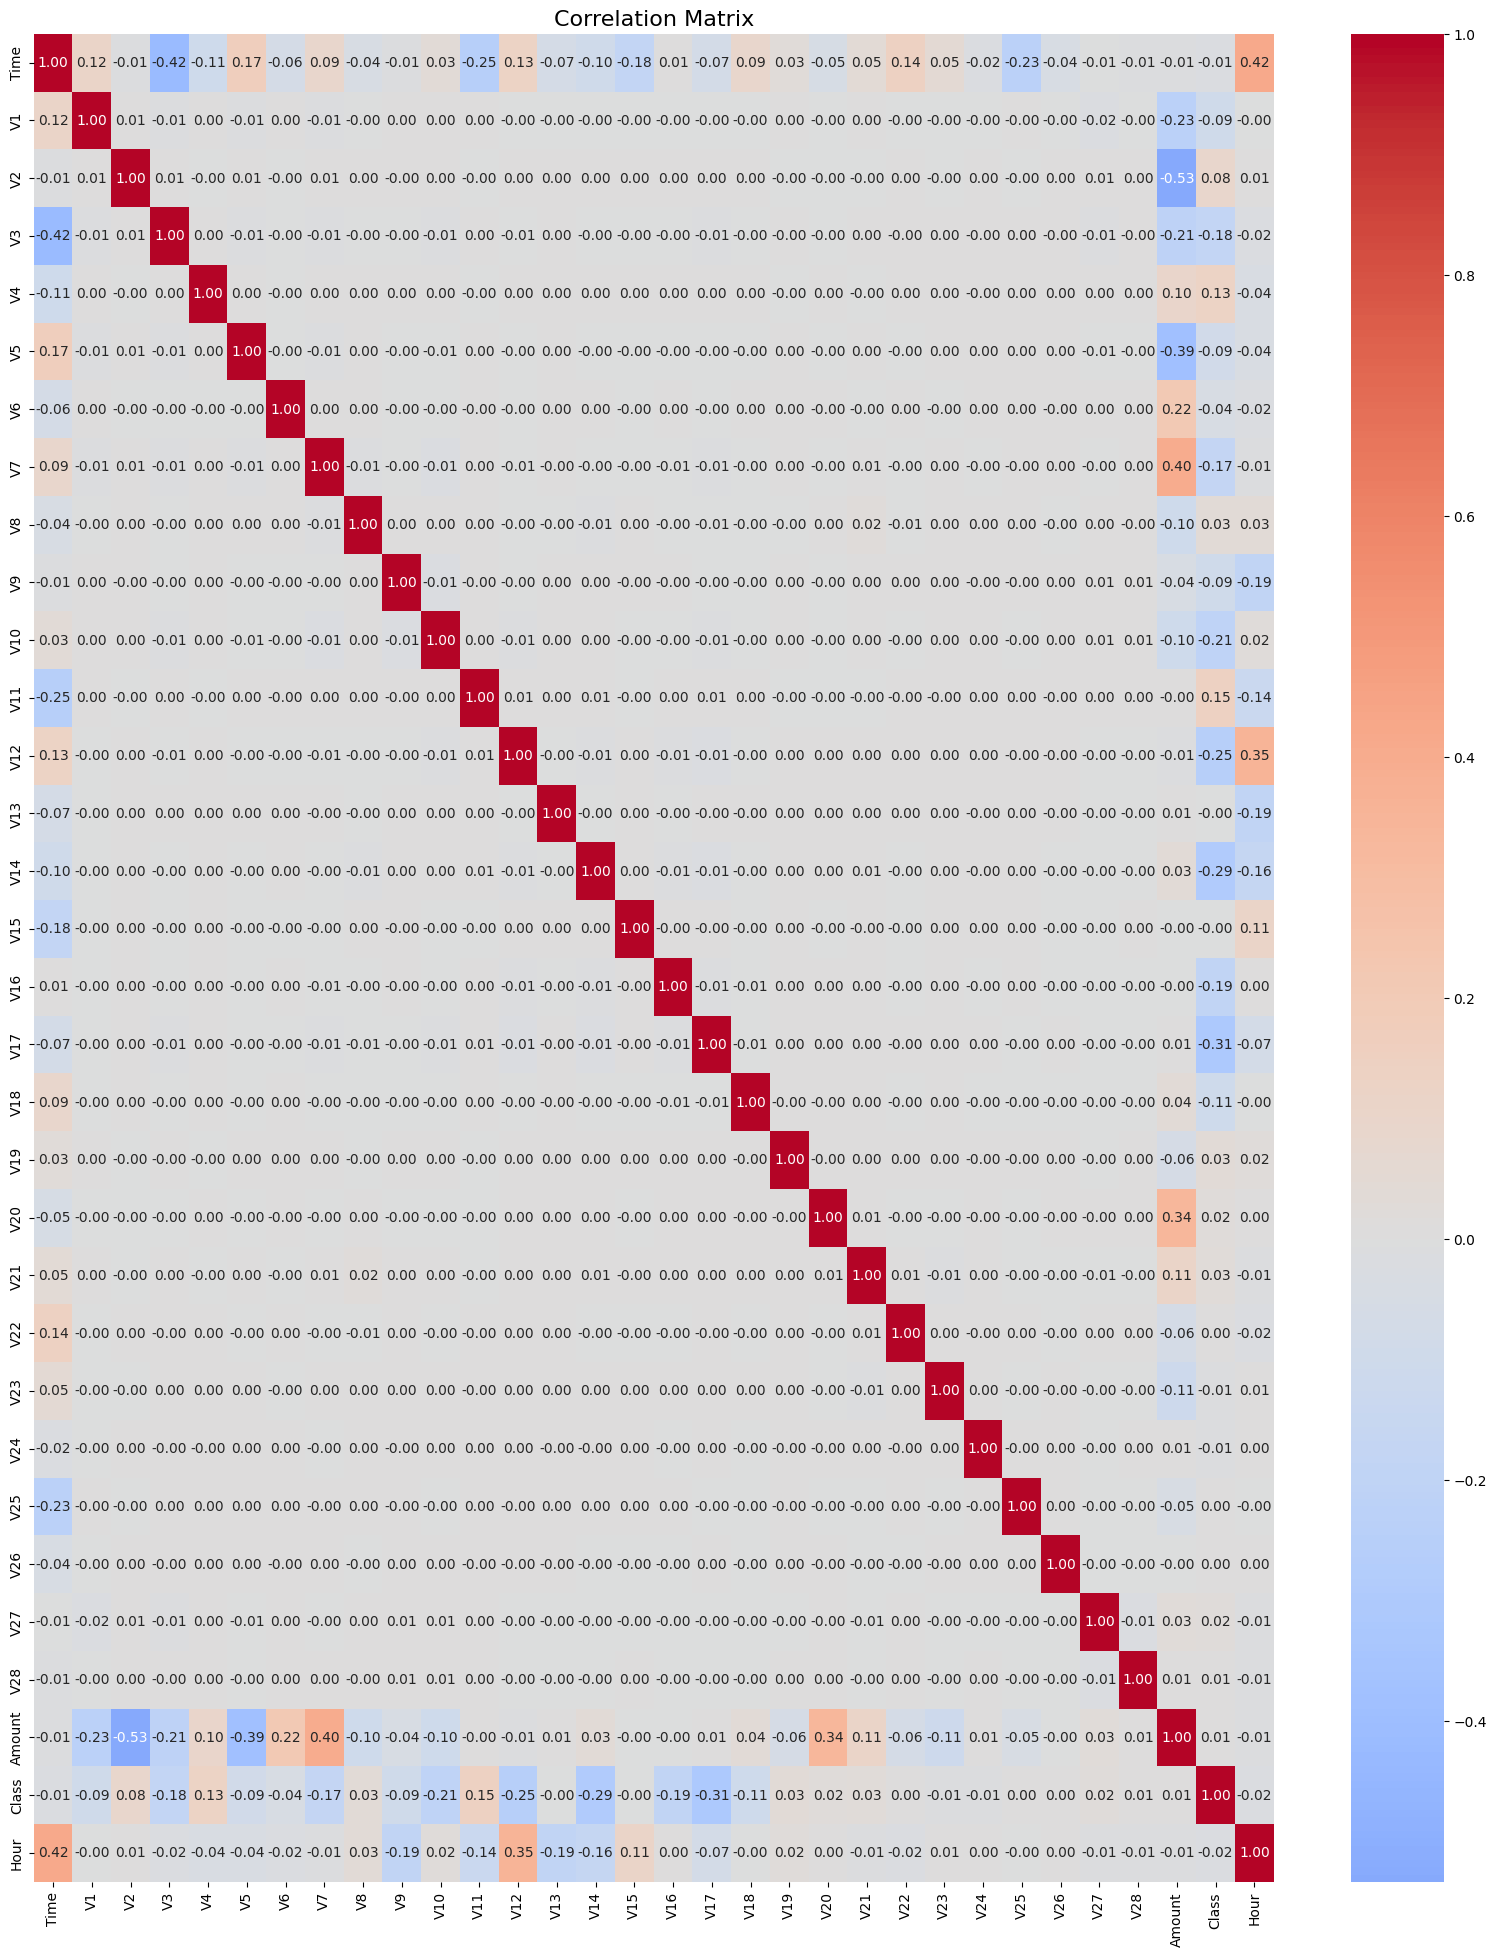

In [ ]:
corr = transactions_df.corr()

plt.figure(figsize=(20,24))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Correlation Matrix", fontsize=16)

plt.show()

## Variables with the most correlation with fraud

## Correlation interpretation

-1 → Strong negative correlation
0  → No correlation
1  → Strong positive correlation

As we can Variable like V17, V14, V12, V10 Are good predictor to reduce the fraud rates manly because the negative value, these veriables should be kept in the data set



Text(0.5, 1.0, 'Correlation Matrix (Fraud Only)')

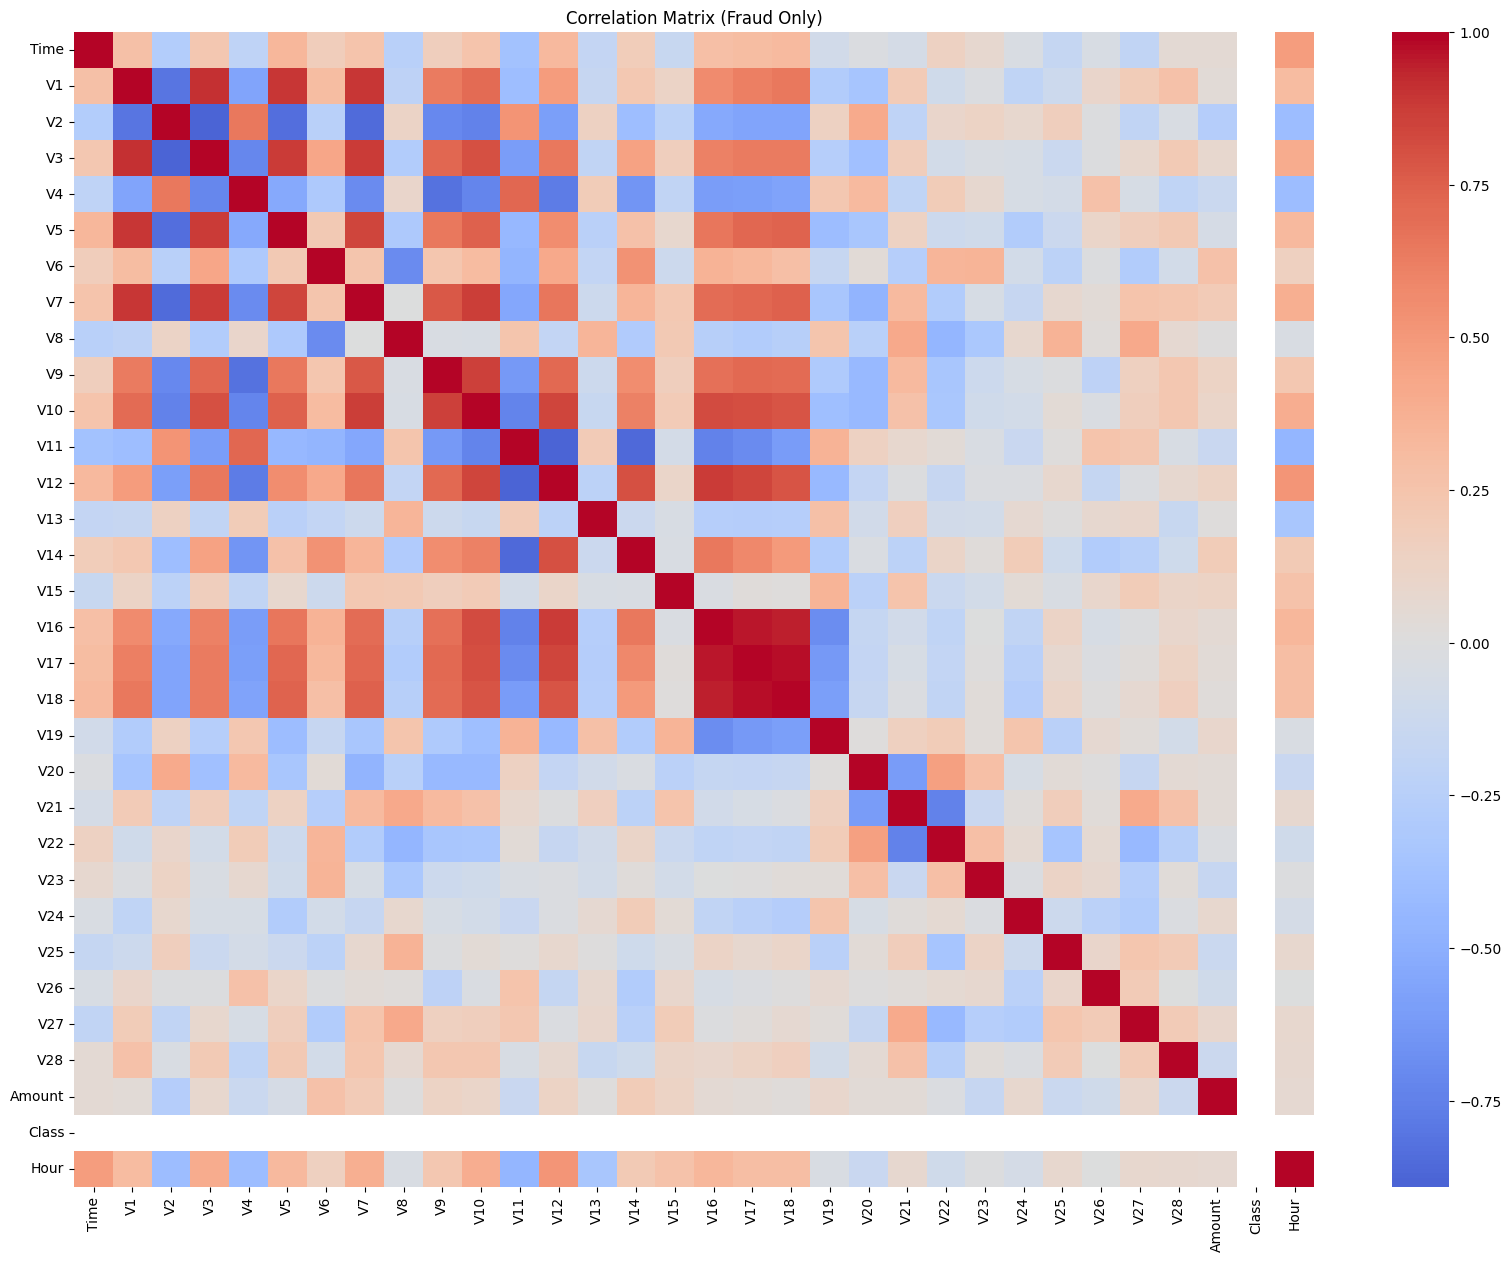

In [ ]:
fraud_corr = transactions_df[transactions_df["Class"]==1].corr()

plt.figure(figsize=(20,15))

sns.heatmap(
    fraud_corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix (Fraud Only)")

## Feature Correlation with Fraud

To better understand which variables are most associated with fraudulent transactions, we compute the correlation between each feature and the target variable (`Class`).

Features with strong positive or negative correlation may provide valuable information for fraud detection models.

In this section we identify the variables most correlated with fraud.

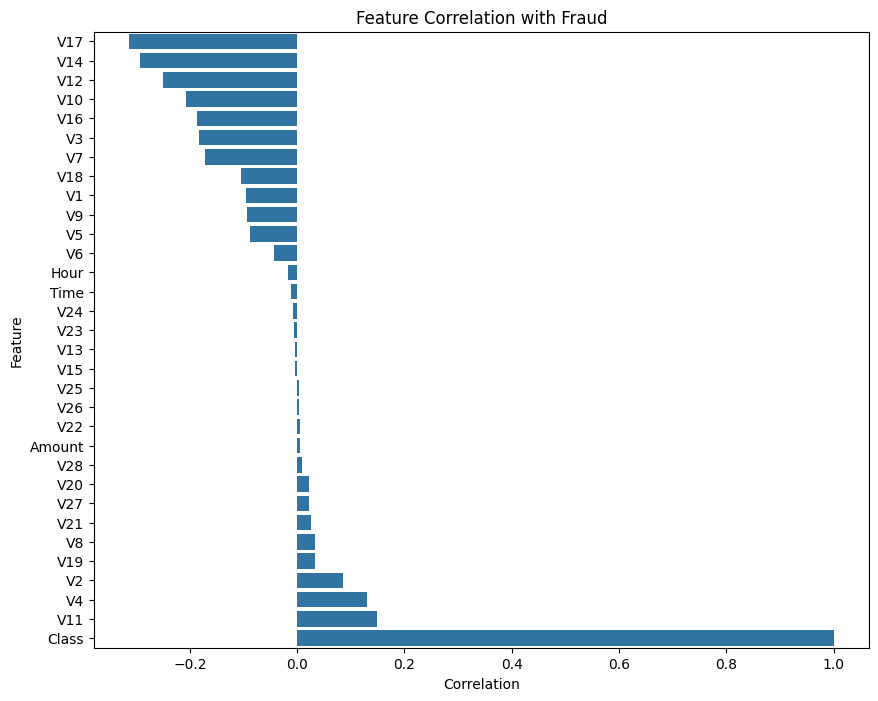

In [ ]:
corr_fraud = transactions_df.corr()["Class"].sort_values()

plt.figure(figsize=(10,8))

sns.barplot(
    x=corr_fraud.values,
    y=corr_fraud.index
)

plt.title("Feature Correlation with Fraud")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.show()

## Distribution of Highly Correlated Features

After identifying the most correlated variables, we examine their distributions for fraudulent and non-fraudulent transactions.

This helps us understand whether fraud cases occupy specific regions of the feature space.

In [ ]:
top_features = corr_fraud.abs().sort_values(ascending=False).head(5).index

top_features

Index(['Class', 'V17', 'V14', 'V12', 'V10'], dtype='object')

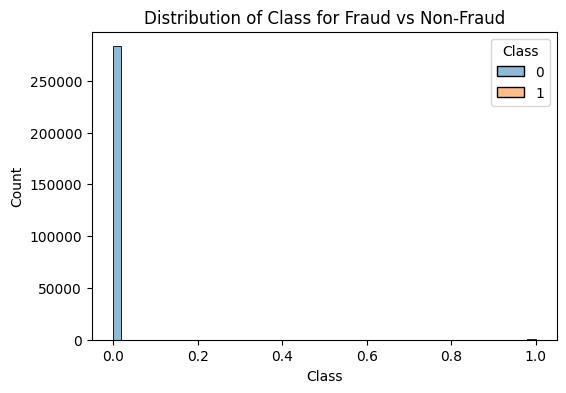

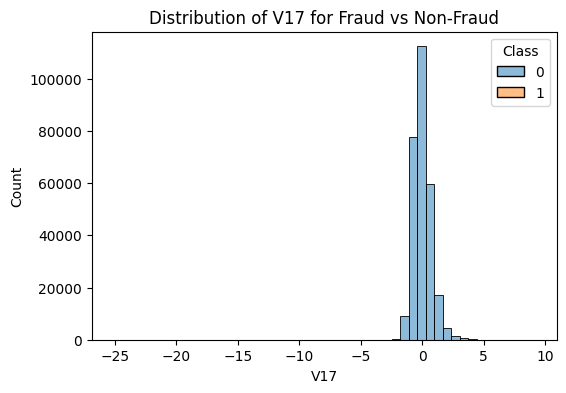

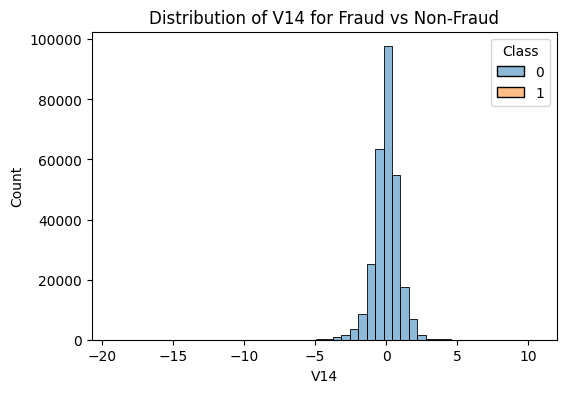

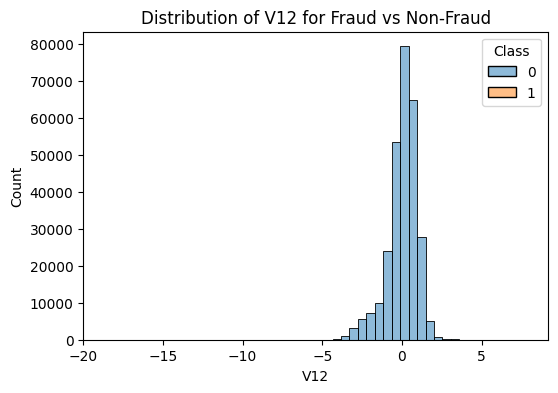

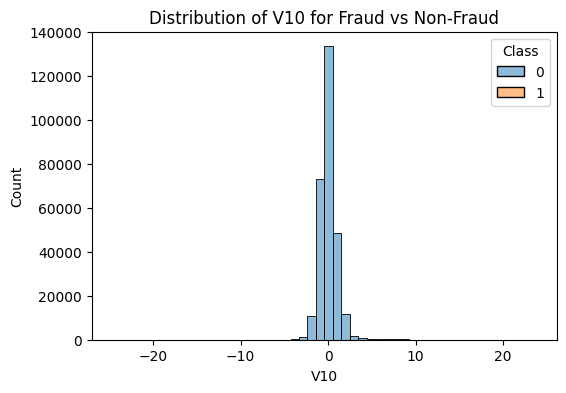

In [ ]:
for feature in top_features:
    
    plt.figure(figsize=(6,4))
    
    sns.histplot(
        data=transactions_df,
        x=feature,
        hue="Class",
        bins=50
    )
    
    plt.title(f"Distribution of {feature} for Fraud vs Non-Fraud")
    
    plt.show()

## Boxplot Analysis

Boxplots allow us to visualize differences in feature distributions between fraudulent and non-fraudulent transactions.

They are particularly useful for detecting outliers and identifying whether fraud tends to occur at extreme values of certain variables.

In [ ]:
for feature in top_features:
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(
        x="Class",
        y=feature,
        data=transactions_df
    )
    
    plt.title(f"{feature} Distribution by Class")
    
    plt.show()

# 5- Statistical Analysis

Kolmogorov-Smirnov Test

In [77]:
fraud = transactions_df[transactions_df["Class"] == 1]["Amount"]
normal = transactions_df[transactions_df["Class"] == 0]["Amount"]

ks_stat, ks_p = stats.ks_2samp(fraud, normal)

print("KS Statistic:", ks_stat)
print("p-value:", ks_p)

KS Statistic: 0.26547753657710993
p-value: 7.446283420073041e-30


The p-value is lower than 0.05, suggesting that the difference between the two distributions is statistically significant.

In [78]:
u_stat, p_val = stats.mannwhitneyu(fraud, normal)

print("Mann-Whitney p-value:", p_val)

Mann-Whitney p-value: 2.68609023836721e-05


The p-value is lower than 0.05, suggestin that the difference between the two distributions is stastistically significant.

<Axes: >

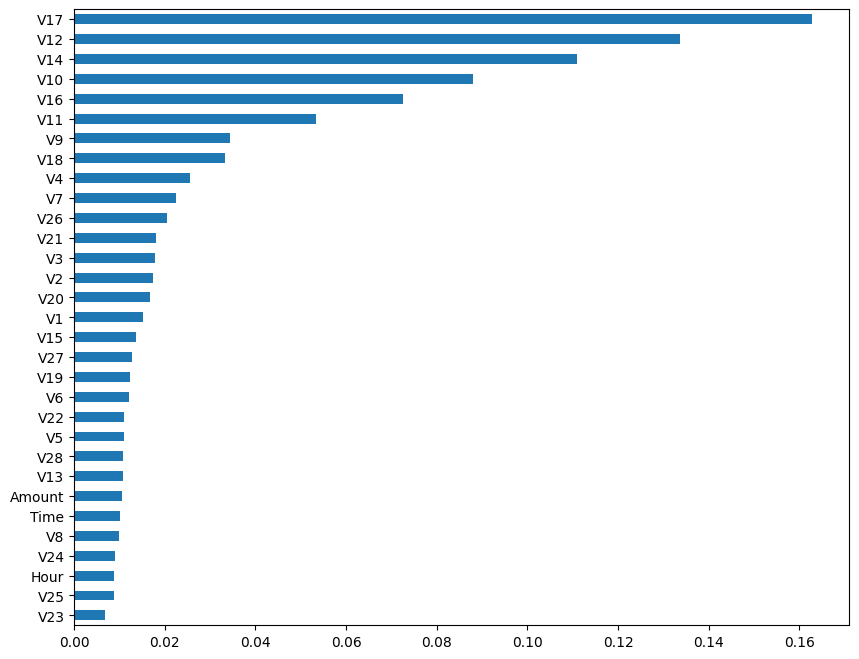

In [75]:
from sklearn.ensemble import RandomForestClassifier

X = transactions_df.drop("Class", axis=1)
y = transactions_df["Class"]

model = RandomForestClassifier()

model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh", figsize=(10,8))

 We trained this preliminary random forest model; the predictions align with the correlation, showing which variables have the highest predictive power for reducing the amount of fraud

In [73]:
corr_matrix = transactions_df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [col for col in upper.columns if any(upper[col] > 0.9)]

print(high_corr)

[]


# 6 - Creating EDA report

In [79]:
pip install markdown pdfkit


   -------------------- ------------------- 1/2 [markdown]
   -------------------- ------------------- 1/2 [markdown]
   -------------------- ------------------- 1/2 [markdown]
   -------------------- ------------------- 1/2 [markdown]
   -------------------- ------------------- 1/2 [markdown]
   ---------------------------------------- 2/2 [markdown]

Note: you may need to restart the kernel to use updated packages.


In [82]:
from pathlib import Path

report_path = Path("../reports/eda_report.md")

report = f"""
# Fraud Detection EDA Report

## Dataset Overview

Rows: {transactions_df.shape[0]}
Columns: {transactions_df.shape[1]}

## Class Distribution

{fraud_ratio.to_string()}

## Data Cleaning

Duplicates removed: {duplicates}

## Statistical Tests

Kolmogorov-Smirnov p-value: {ks_p}

Mann-Whitney p-value: {p_val}

"""

report_path.write_text(report)

print("Markdown report created at:", report_path.resolve())

Markdown report created at: C:\Users\Pichau\Documents\Github\fraud-ml-platform\reports\eda_report.md


## Conclusion

Key observations from the dataset analysis:

- The dataset is highly imbalanced.
- Fraud cases represent less than 1% of transactions.
- Feature distributions suggest potential separability between classes.

These insights will guide feature engineering and model training in the next steps.